# `prepare_one` — qstack-MLIR end-to-end demo

This notebook mirrors the legacy `examples/0.bell.ipynb` workflow on the
new MLIR stack: a `%%qasm` cell magic parses + lowers the surface
language to a `qstack` `ModuleOp`, and a `Machine` runs shots that come
back wrapped in a `Results` object with `plot_histogram()`.


In [1]:
%load_ext qstack.jupyter

In [2]:
%%qasm
QSTACKQASM 0.1;
include "qstack/cliffords.inc";

extern selector repeat_until_one(bit) -> int;

def prepare_one(qubit q) {
  qreg ancilla[1];
  bit m;
  h q;
  cx q, ancilla[0];
  measure ancilla[0] -> m;
  switch (repeat_until_one(m)) {
    case 0: { }
    case 1: { prepare_one q; }
  }
}

qreg q[1];
creg c[1];
prepare_one q[0];
measure q[0] -> c[0];

<ModuleOp 4580243312(operands=[], results=[], successors=[], properties={}, attributes={}, regions=[<Region 4581458000>], parent=None, _next_op=None, _prev_op=None)>

In [3]:
print(module)

builtin.module {
  qstack.selector @repeat_until_one arity 1
  qstack.kernel @__qstack_case_0_1 <[!qstack.qubit], [!qstack.qubit]> allocates 0 {
  ^bb0(%0: !qstack.qubit):
    qstack.return %0 : !qstack.qubit
  }
  qstack.kernel @__qstack_case_1_2 <[!qstack.qubit], [!qstack.qubit]> allocates 0 {
  ^bb0(%0: !qstack.qubit):
    %1 = qstack.call @prepare_one(%0) : (!qstack.qubit) -> !qstack.qubit
    qstack.return %1 : !qstack.qubit
  }
  qstack.kernel @prepare_one <[!qstack.qubit], [!qstack.qubit]> allocates 1 {
  ^bb0(%0: !qstack.qubit, %1: !qstack.qubit):
    %2 = cliffords.h %0
    %3, %4 = cliffords.cx %2, %1
    %5 = qstack.measure %4
    %6 = qstack.select @repeat_until_one(%5) [%3] {"0" = @__qstack_case_0_1, "1" = @__qstack_case_1_2} : (!qstack.qubit) -> !qstack.qubit
    qstack.return %6 : !qstack.qubit
  }
  qstack.kernel @main <[], [!qstack.bit]> allocates 1 {
  ^bb0(%0: !qstack.qubit):
    %1 = qstack.call @prepare_one(%0) : (!qstack.qubit) -> !qstack.qubit
    %2 = qstack.mea

In [4]:
from qstack.runtime import CallbackRegistry, Machine

reg = CallbackRegistry()

@reg.selector("repeat_until_one")
def _pick(bits):
    # case 0 -> done, case 1 -> retry
    return "0" if bits[0] == 1 else "1"

machine = Machine(module, num_qubits=4, registry=reg)
results = machine.eval(shots=1000)
results

Results(1000 shots, histogram={(1,): 1000})

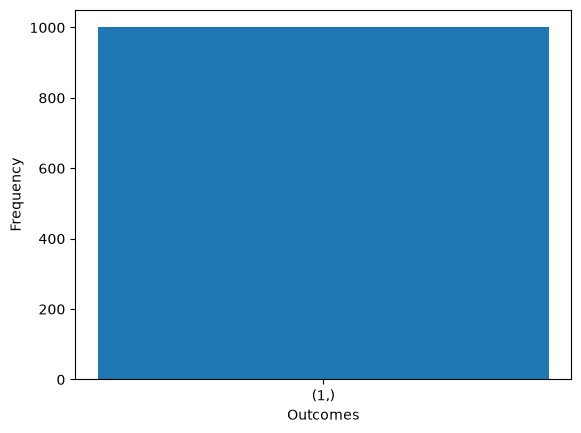

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [5]:
results.plot_histogram()